# CO2 Emission Gap Among Countries: Clustering and PCA

This project explores agro-food related CO2 emissions across countries to identify structural differences, compare major emission drivers, and group countries with similar profiles using clustering and principal component analysis (PCA).

## Project overview
The analysis combines country-level data on emissions, temperature, and population metrics to investigate how economic and environmental factors shape emission profiles. It highlights country clusters and quantifies the contribution of key drivers such as rice cultivation, organic soil emissions, urbanization, and total population.

## Setup notes
1. Place `Agrofood_co2_emission.csv` in the same folder as this notebook.
2. Install the required libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn`.
3. Run the notebook from the project directory so the relative file path resolves correctly.

## Dataset overview
The dataset contains annual country-level agricultural and food-system emissions together with related climate and demographic indicators.

# Importing

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Agrofood_co2_emission.csv')

# Data Outline

**1) Data Frame**

In [ ]:
df.head()

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,...,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,...,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,...,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,...,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583
3,Afghanistan,1993,14.7237,0.0557,230.8175,686.00,0.0,11.712073,54.3617,-2388.803,...,352.2947,0.0,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917
4,Afghanistan,1994,14.7237,0.0557,242.0494,705.60,0.0,11.712073,53.9874,-2388.803,...,367.6784,0.0,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250


**2) Features Description**

* Savanna fires: Emissions from fires in savanna ecosystems.
* Forest fires: Emissions from fires in forested areas.
* Crop Residues: Emissions from burning or decomposing leftover plant material after crop harvesting.
* Rice Cultivation: Emissions from methane released during rice cultivation.
* Drained organic soils (CO2): Emissions from carbon dioxide released when draining organic soils.
* Pesticides Manufacturing: Emissions from the production of pesticides.
* Food Transport: Emissions from transporting food products.
* Forestland: Land covered by forests.
* Net Forest conversion: Change in forest area due to deforestation and afforestation.
* Food Household Consumption: Emissions from food consumption at the household level.
* Food Retail: Emissions from the operation of retail establishments selling food.
* On-farm Electricity Use: Electricity consumption on farms.
* Food Packaging: Emissions from the production and disposal of food packaging materials.
* Agrifood Systems Waste Disposal: Emissions from waste disposal in the agrifood system.
* Food Processing: Emissions from processing food products.
* Fertilizers Manufacturing: Emissions from the production of fertilizers.
* IPPU: Emissions from industrial processes and product use.
* Manure applied to Soils: Emissions from applying animal manure to agricultural soils.
* Manure left on Pasture: Emissions from animal manure on pasture or grazing land.
* Manure Management: Emissions from managing and treating animal manure.
* Fires in organic soils: Emissions from fires in organic soils.
* Fires in humid tropical forests: Emissions from fires in humid tropical forests.
* On-farm energy use: Energy consumption on farms.
* Rural population: Number of people living in rural areas.
* Urban population: Number of people living in urban areas.
* Total Population - Male: Total number of male individuals in the population.
* Total Population - Female: Total number of female individuals in the population.
* total_emission: Total greenhouse gas emissions from various sources.
* Average Temperature °C: The average increasing of temperature (by year) in degrees Celsius,

**3) Data Information**

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6965 entries, 0 to 6964
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             6965 non-null   str    
 1   Year                             6965 non-null   int64  
 2   Savanna fires                    6934 non-null   float64
 3   Forest fires                     6872 non-null   float64
 4   Crop Residues                    5576 non-null   float64
 5   Rice Cultivation                 6965 non-null   float64
 6   Drained organic soils (CO2)      6965 non-null   float64
 7   Pesticides Manufacturing         6965 non-null   float64
 8   Food Transport                   6965 non-null   float64
 9   Forestland                       6472 non-null   float64
 10  Net Forest conversion            6472 non-null   float64
 11  Food Household Consumption       6492 non-null   float64
 12  Food Retail                    

**4) Data Description**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,6965.0,2.005125e+03,8.894665e+00,1990.000000,1997.000000,2.005000e+03,2.013000e+03,2.020000e+03
Savanna fires,6934.0,1.188391e+03,5.246288e+03,0.000000,0.000000,1.651850e+00,1.110814e+02,1.146164e+05
Forest fires,6872.0,9.193022e+02,3.720079e+03,0.000000,0.000000,5.179000e-01,6.495077e+01,5.222763e+04
Crop Residues,5576.0,9.987063e+02,3.700345e+03,0.000200,11.006525,1.036982e+02,3.776410e+02,3.349007e+04
Rice Cultivation,6965.0,4.259667e+03,1.761383e+04,0.000000,181.260800,5.348174e+02,1.536640e+03,1.649153e+05
Drained organic soils (CO2),6965.0,3.503229e+03,1.586145e+04,0.000000,0.000000,0.000000e+00,6.904088e+02,2.410251e+05
Pesticides Manufacturing,6965.0,3.334184e+02,1.429159e+03,0.000000,6.000000,1.300000e+01,1.163255e+02,1.645900e+04
Food Transport,6965.0,1.939582e+03,5.616749e+03,0.000100,27.958600,2.049628e+02,1.207001e+03,6.794576e+04
Forestland,6472.0,-1.782829e+04,8.183221e+04,-797183.079000,-2848.350000,-6.292000e+01,0.000000e+00,1.711211e+05
Net Forest conversion,6472.0,1.760564e+04,1.011575e+05,0.000000,0.000000,4.444000e+01,4.701746e+03,1.605106e+06


# Data Visualization

**1) Total emission by years**

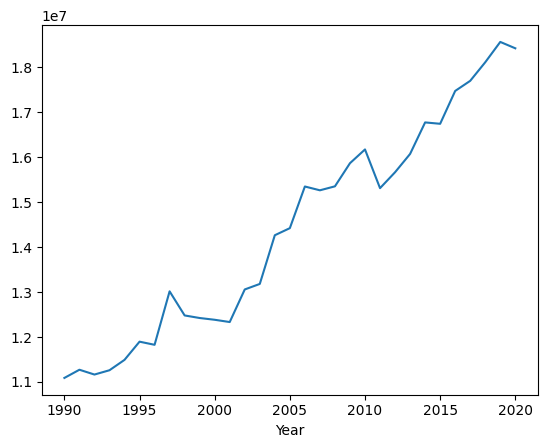

In [ ]:
df.groupby('Year')['total_emission'].sum().plot();

**2) 20 countries by most total emission**

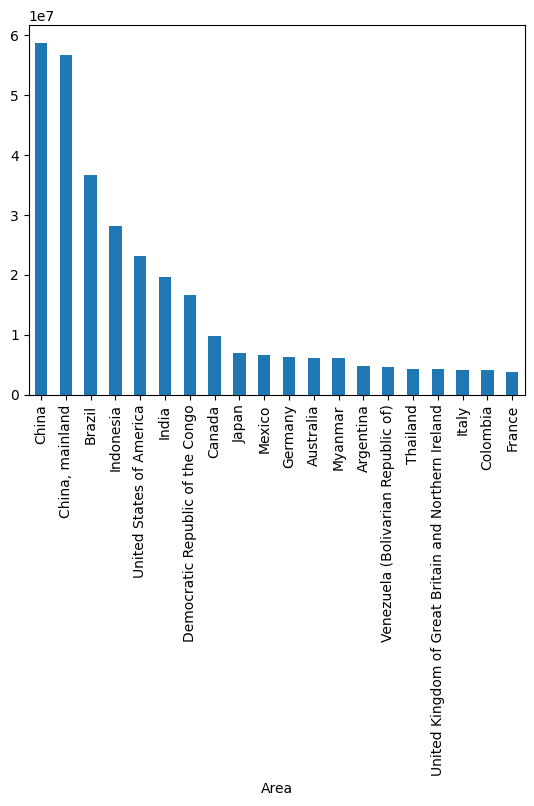

In [ ]:
df.groupby('Area')['total_emission'].sum().sort_values(ascending=False).head(20).plot.bar();

**3) 20 countries by less total emission**

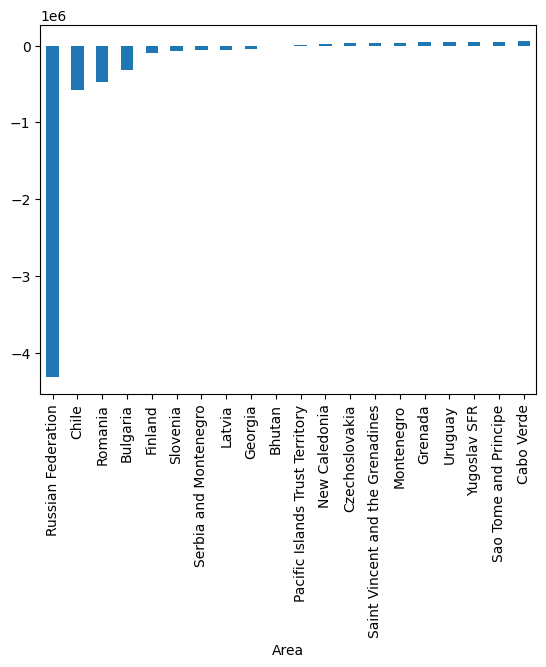

In [ ]:
df.groupby('Area')['total_emission'].sum().sort_values(ascending=True).head(20).plot.bar();

**4) Russia, China and India - Total emission by years**

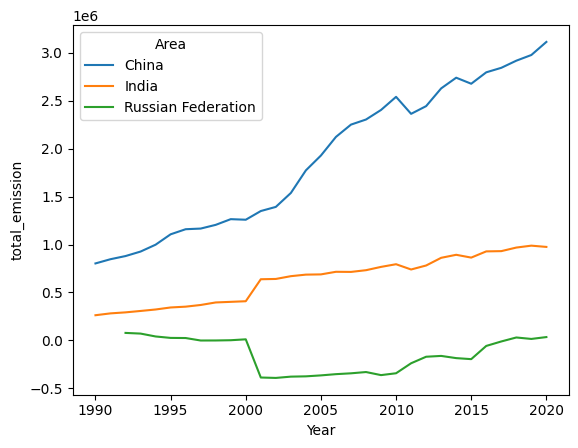

In [ ]:
sns.lineplot(data=df[(df['Area']=='Russian Federation')|(df['Area']=='China')|(df['Area']=='India')],x='Year',y='total_emission',hue='Area');

**5
)  Russia, China and India - Average Temperature by years**

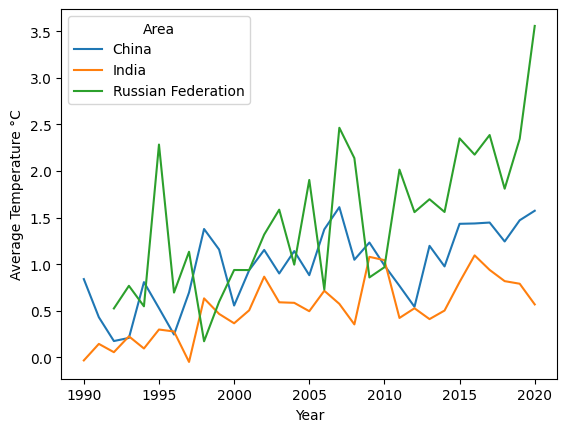

In [ ]:
sns.lineplot(data=df[(df['Area']=='Russian Federation')|(df['Area']=='China')|(df['Area']=='India')],x='Year',y='Average Temperature °C',hue='Area');

*Total emission of Russia is very lower than China. But the  increase of Average Temperature of Russia is higher than that of China.*

**9) Countries whose total emission in 2019 is minus**

In [ ]:
df_2019=df[df['Year']==2019]

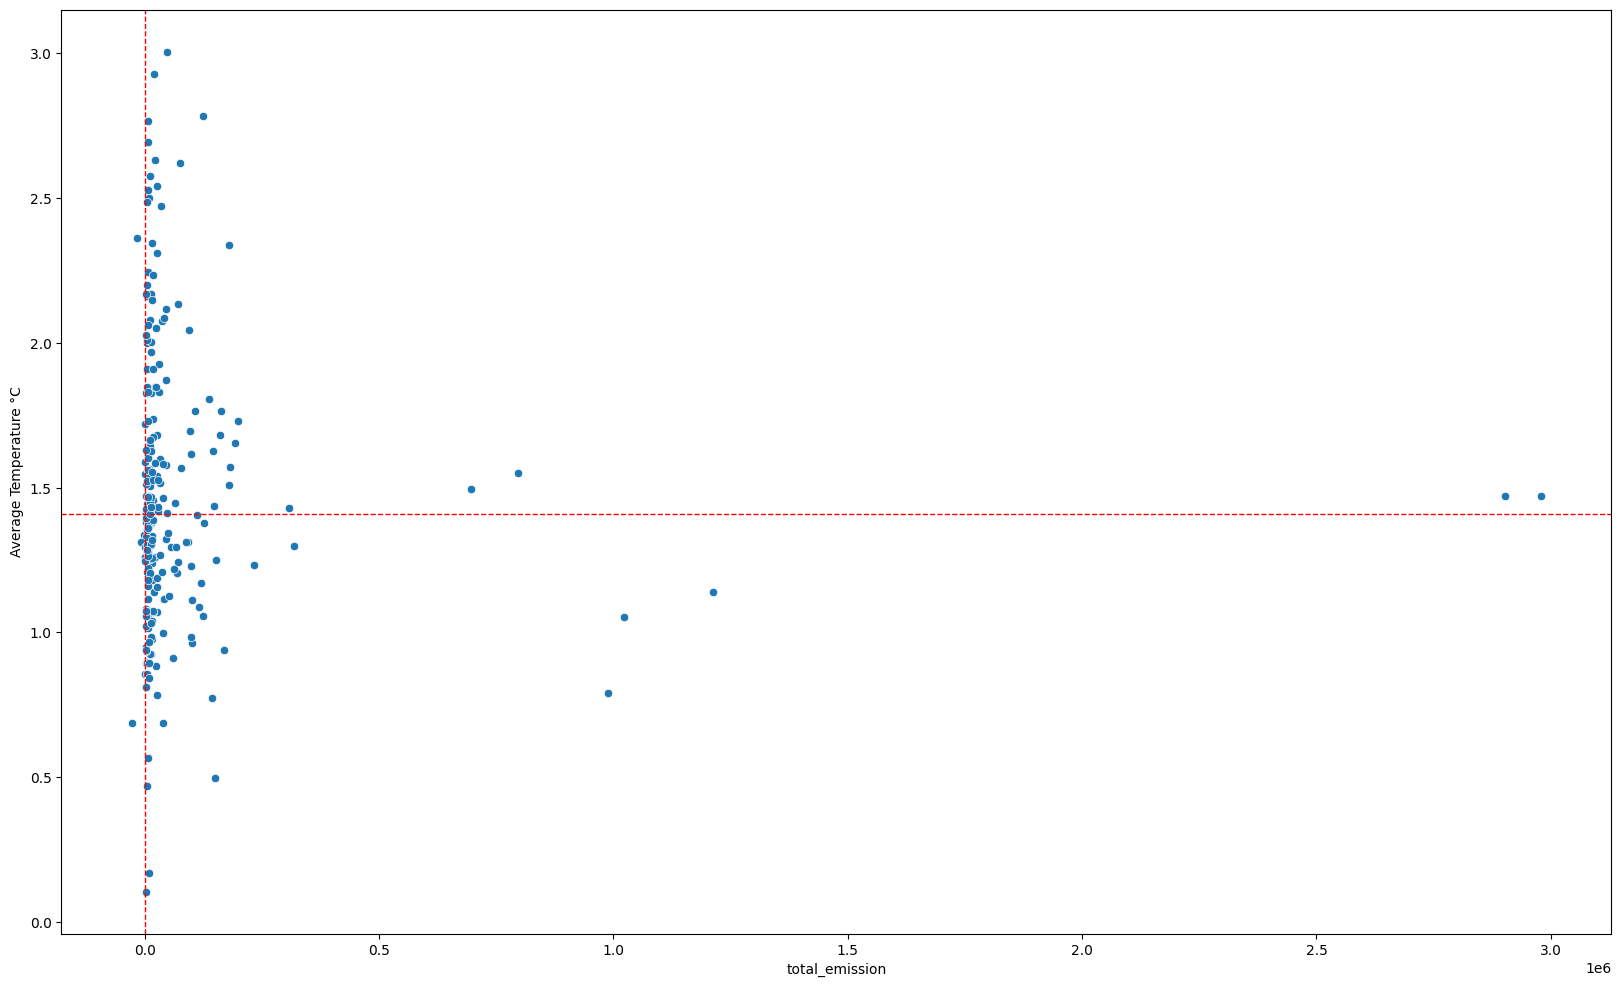

In [ ]:
plt.figure(figsize=(20,12))
plt.axvline(x=0,color='red',lw=1,ls='--',alpha=1)
plt.axhline(y=df_2019['Average Temperature °C'].median(),color='red',lw=1,ls='--',alpha=1)
sns.scatterplot(data=df_2019,x='total_emission',y='Average Temperature °C');

*In 2019, there are some countries which have below 0 'total emission' and  above median 'Average Temperature °C'.*

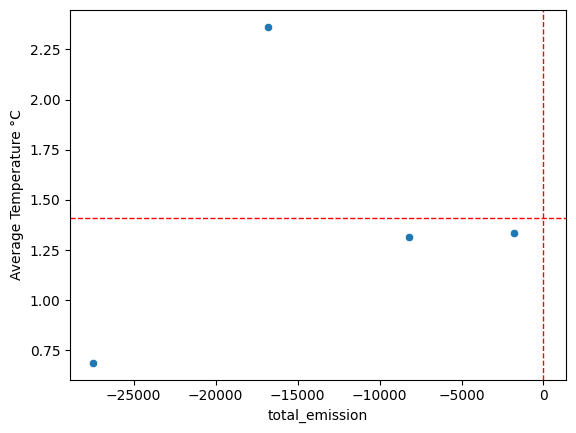

In [ ]:
plt.axvline(x=0,color='red',lw=1,ls='--',alpha=1)
plt.axhline(y=df_2019['Average Temperature °C'].median(),color='red',lw=1,ls='--',alpha=1)
sns.scatterplot(data=df_2019[df_2019['total_emission']<=0],x='total_emission',y='Average Temperature °C');

In [ ]:
df_2019[df_2019['total_emission']<=0].loc[:,['Area','total_emission','Average Temperature °C']]

,Area,total_emission,Average Temperature °C
951,Bulgaria,-16771.280600,2.363083
1292,Chile,-27500.881600,0.688583
1602,Costa Rica,-1804.920583,1.336172
2492,Ghana,-8222.224583,1.313250


*For example, according to the data Bulgaria has negative land-use change and forestry (-33.8 million ton) in 2019. It contributes to the minus total emission.*

# Clustering and PCA

This section standardizes the 2020 dataset, clusters countries into groups, and applies PCA to interpret the main drivers behind the emission gap between countries.

**1) Focus on 2020 data**

In [ ]:
df_2020=df[df['Year']==2020]

**2) Drop features which include MaN**

In [ ]:
df_2020=df_2020.dropna(axis=1)

In [ ]:
df_2020.info()

<class 'pandas.DataFrame'>
Index: 227 entries, 30 to 6964
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             227 non-null    str    
 1   Year                             227 non-null    int64  
 2   Rice Cultivation                 227 non-null    float64
 3   Drained organic soils (CO2)      227 non-null    float64
 4   Pesticides Manufacturing         227 non-null    float64
 5   Food Transport                   227 non-null    float64
 6   Food Retail                      227 non-null    float64
 7   On-farm Electricity Use          227 non-null    float64
 8   Food Packaging                   227 non-null    float64
 9   Agrifood Systems Waste Disposal  227 non-null    float64
 10  Food Processing                  227 non-null    float64
 11  Fertilizers Manufacturing        227 non-null    float64
 12  Manure left on Pasture           227

In [ ]:
df_2020=df_2020.reset_index(drop=True)
df_2020.head()

,Area,Year,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Food Retail,On-farm Electricity Use,Food Packaging,Agrifood Systems Waste Disposal,Food Processing,Fertilizers Manufacturing,Manure left on Pasture,Fires in organic soils,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,2020,578.415600,0.000,107.628149,545.3243,630.7575,101.731000,353.930640,3597.1846,1641.652932,38.217900,2743.594500,0.0,28150604.0,9904337.0,19692301.0,19279930.0,14032.420621,0.209250
1,Albania,2020,248.061497,105.631,8.000000,262.7122,186.3487,1.055900,57.082900,687.6005,73.852500,377.407900,294.497200,0.0,1114672.0,1827362.0,1433767.0,1433082.0,4411.888497,1.554167
2,Algeria,2020,1.317100,0.000,48.000000,4307.4471,922.8476,626.686500,1884.219400,9494.9015,2528.609200,2744.623400,3960.468600,0.0,11382345.0,31950910.0,22132899.0,21318767.0,69603.093000,1.882083
3,American Samoa,2020,1410.445506,0.000,11.481085,9.6998,3.8553,17.004663,77.393651,2.1052,43.597700,2005.792129,2148.251693,0.0,7169.0,48630.0,22921.0,23268.0,5708.186226,1.409833
4,Andorra,2020,926.342278,0.000,11.481085,30.7624,10.2423,17.004663,67.631366,15.9781,451.196291,1664.257391,2313.955884,0.0,9327.0,67857.0,39615.0,38084.0,5599.108259,2.388083


In [ ]:
df_clus=df_2020.drop(['Area','Year'],axis=1)
df_clus.head()

,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Food Retail,On-farm Electricity Use,Food Packaging,Agrifood Systems Waste Disposal,Food Processing,Fertilizers Manufacturing,Manure left on Pasture,Fires in organic soils,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,578.415600,0.000,107.628149,545.3243,630.7575,101.731000,353.930640,3597.1846,1641.652932,38.217900,2743.594500,0.0,28150604.0,9904337.0,19692301.0,19279930.0,14032.420621,0.209250
1,248.061497,105.631,8.000000,262.7122,186.3487,1.055900,57.082900,687.6005,73.852500,377.407900,294.497200,0.0,1114672.0,1827362.0,1433767.0,1433082.0,4411.888497,1.554167
2,1.317100,0.000,48.000000,4307.4471,922.8476,626.686500,1884.219400,9494.9015,2528.609200,2744.623400,3960.468600,0.0,11382345.0,31950910.0,22132899.0,21318767.0,69603.093000,1.882083
3,1410.445506,0.000,11.481085,9.6998,3.8553,17.004663,77.393651,2.1052,43.597700,2005.792129,2148.251693,0.0,7169.0,48630.0,22921.0,23268.0,5708.186226,1.409833
4,926.342278,0.000,11.481085,30.7624,10.2423,17.004663,67.631366,15.9781,451.196291,1664.257391,2313.955884,0.0,9327.0,67857.0,39615.0,38084.0,5599.108259,2.388083


**3) Standardizing**

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_sc = sc.fit_transform(df_clus)
df_sc = pd.DataFrame(df_sc, columns=df_clus.columns)

**4) Clustering**

In [ ]:
from sklearn.cluster import KMeans

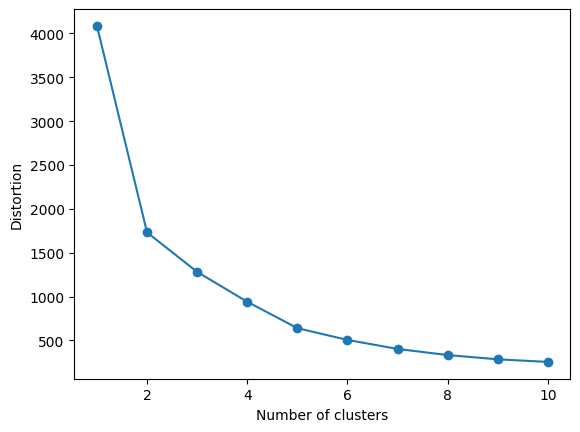

In [ ]:
distortions = []

for i  in range(1,11):
    km = KMeans(n_clusters=i,
                init='k-means++',
                n_init=10,
                max_iter=300,
                random_state=0)
    km.fit(df_sc)
    distortions.append(km.inertia_)

plt.plot(range(1,11),distortions,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

In [65]:
model = KMeans(n_clusters=4, random_state=1)
model.fit(df_sc)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",1
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 18)","[

In [66]:
cluster = model.labels_

In [67]:
df_clus['Country']=df_2020['Area']

In [68]:
df_clus['Cluster']=cluster

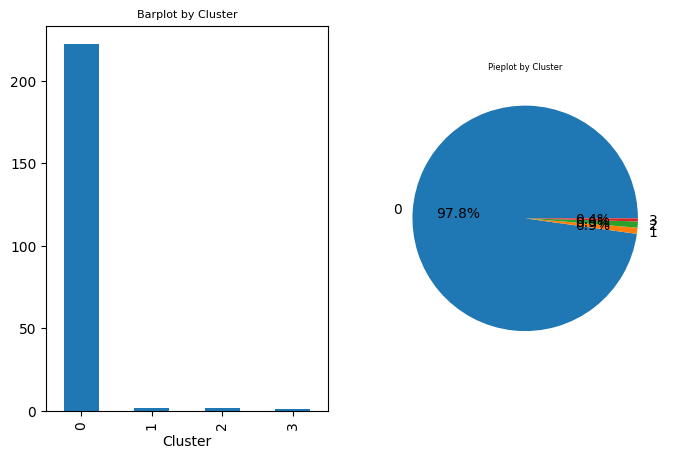

In [69]:
plt.figure(figsize=(8, 5))

plt.subplot(1, 2, 1)
df_clus.groupby('Cluster')['Country'].count().plot.bar()
plt.title('Barplot by Cluster',fontsize=8)

plt.subplot(1, 2, 2)
df_clus.groupby('Cluster')['Country'].count().plot.pie(autopct="%1.1f%%")
plt.title('Pieplot by Cluster',fontsize=6);

<Axes: xlabel='Cluster'>

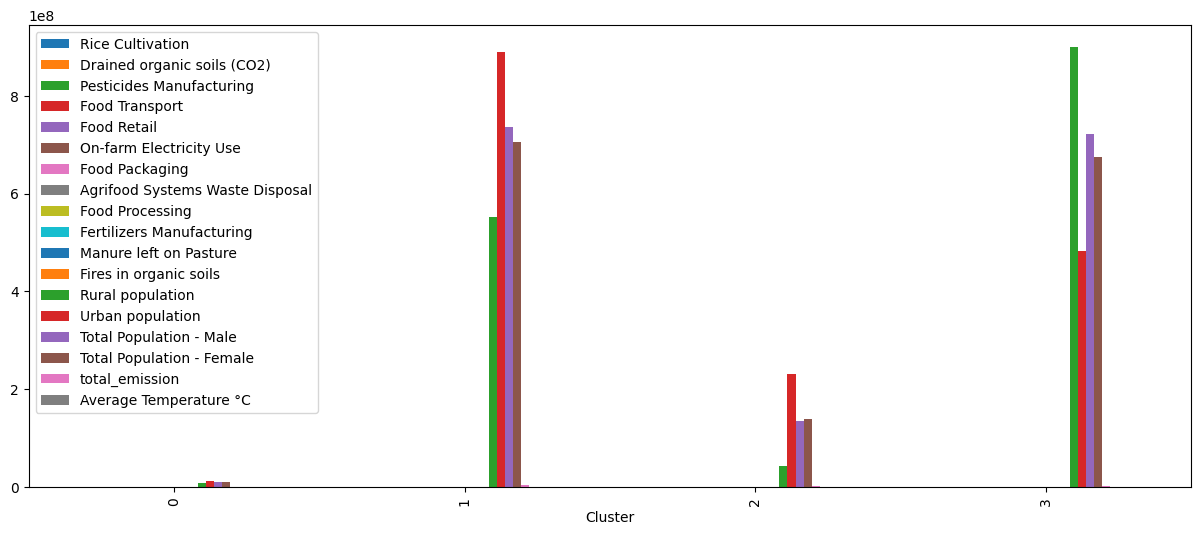

In [72]:
df_clus.groupby('Cluster').mean(numeric_only=True).plot.bar(figsize=(15, 6))

In [ ]:
df_2020.columns

Index(['Area', 'Year', 'Rice Cultivation', 'Drained organic soils (CO2)',
       'Pesticides Manufacturing', 'Food Transport', 'Food Retail',
       'On-farm Electricity Use', 'Food Packaging',
       'Agrifood Systems Waste Disposal', 'Food Processing',
       'Fertilizers Manufacturing', 'Manure left on Pasture',
       'Fires in organic soils', 'Rural population', 'Urban population',
       'Total Population - Male', 'Total Population - Female',
       'total_emission', 'Average Temperature °C'],
      dtype='object')

In [ ]:
clus_col=['Rice Cultivation', 'Drained organic soils (CO2)',
       'Pesticides Manufacturing', 'Food Transport', 'Food Retail',
       'On-farm Electricity Use', 'Food Packaging',
       'Agrifood Systems Waste Disposal', 'Food Processing',
       'Fertilizers Manufacturing', 'Manure left on Pasture',
       'Fires in organic soils', 'Rural population', 'Urban population',
       'Total Population - Male', 'Total Population - Female',
       'total_emission', 'Average Temperature °C']

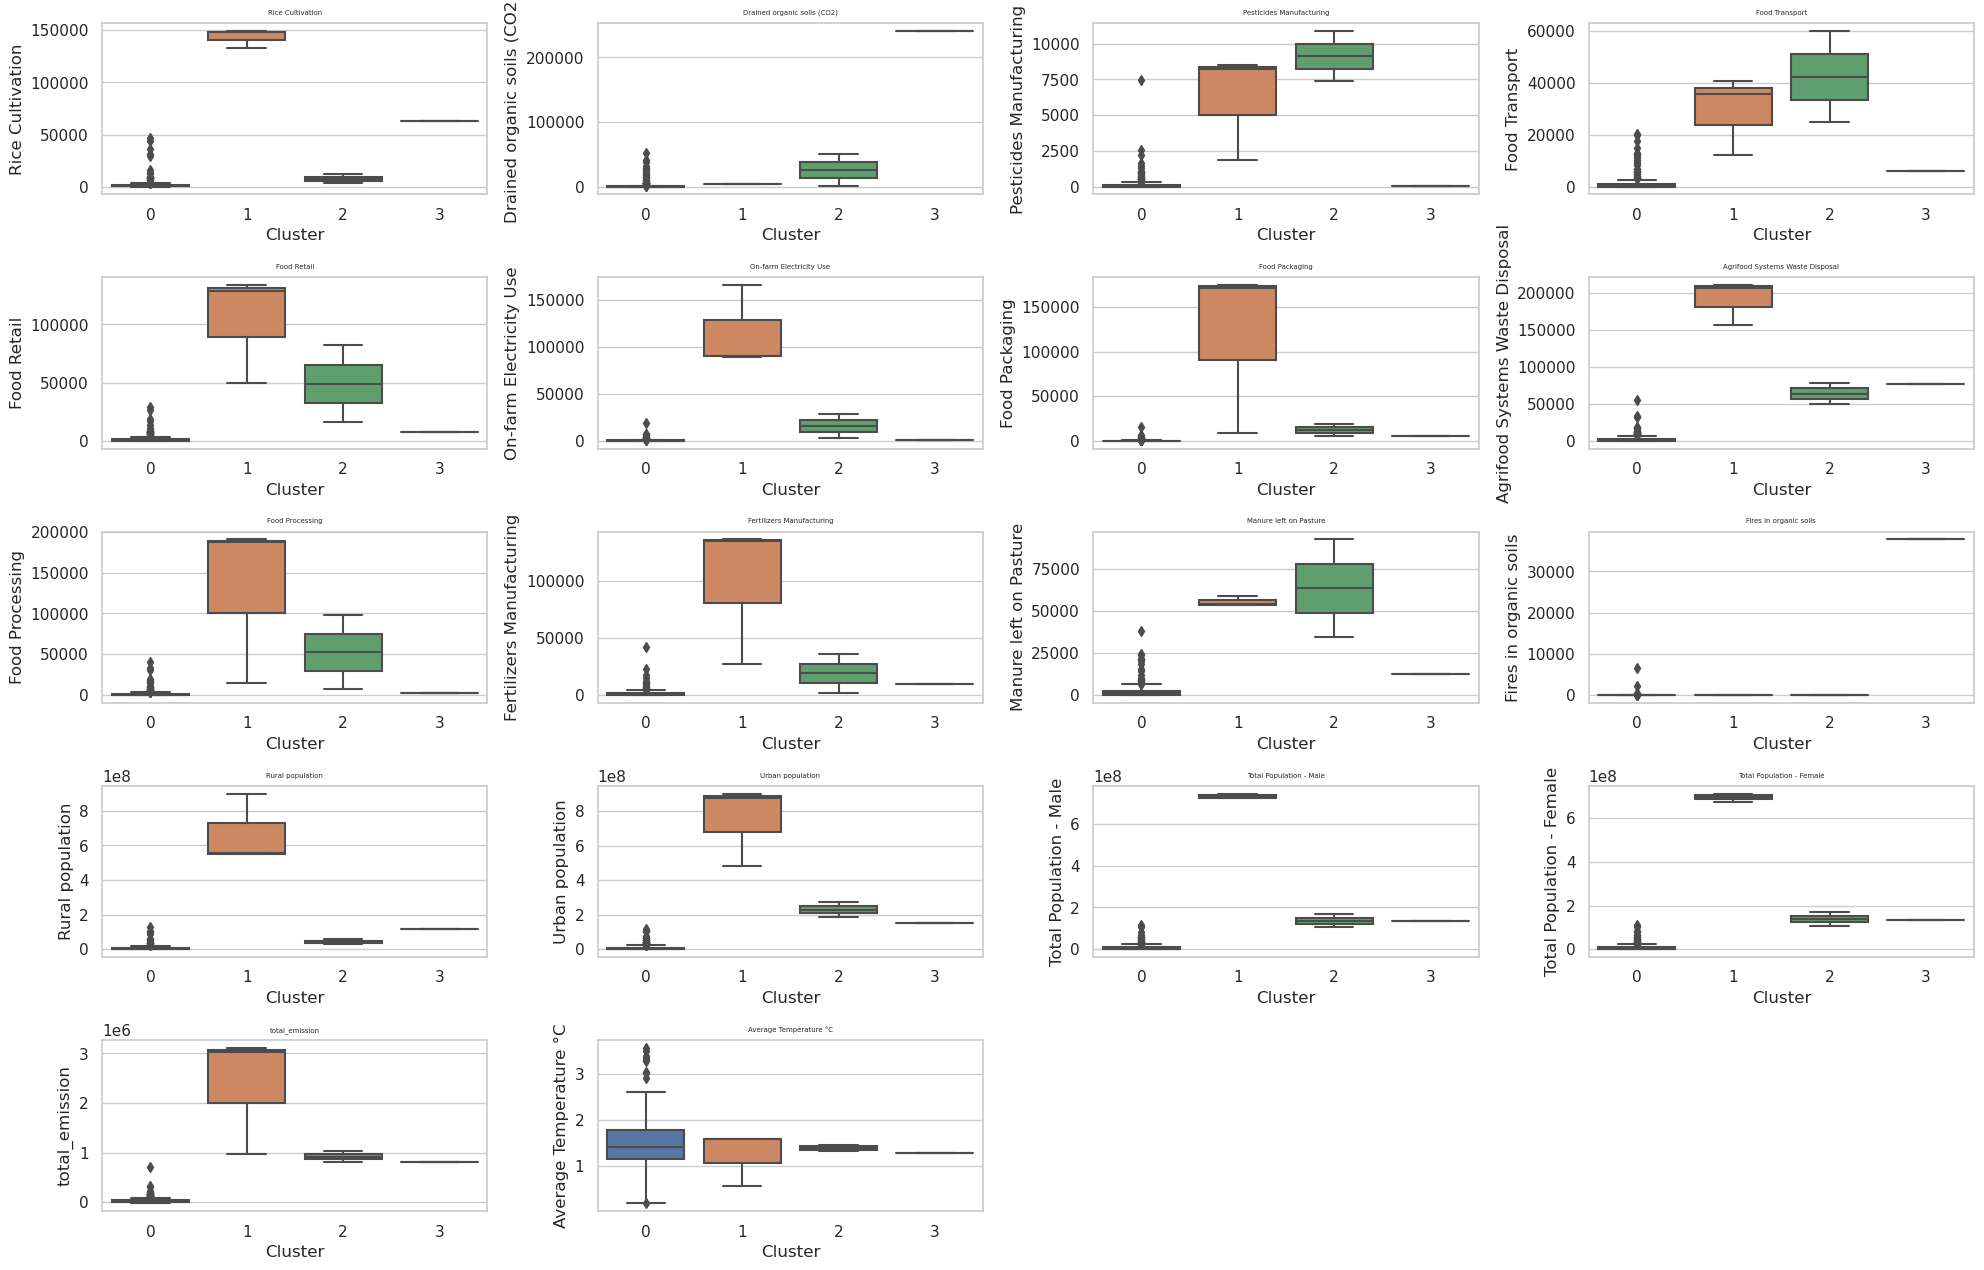

In [ ]:
fig = plt.figure(figsize=(20,20))

for i in range(len(clus_col)):
    plt.subplot(8,4,i+1)
    sns.boxplot(df_clus,y=df_clus[clus_col[i]],x=df_clus['Cluster'])
    plt.title(clus_col[i],fontsize=5)
    
plt.tight_layout()
plt.show()

In [ ]:
clus_col2=['Rice Cultivation', 'Drained organic soils (CO2)',
       'Pesticides Manufacturing', 'Food Transport', 'Food Retail',
       'On-farm Electricity Use', 'Food Packaging',
       'Agrifood Systems Waste Disposal', 'Food Processing',
       'Fertilizers Manufacturing', 'Manure left on Pasture',
       'Fires in organic soils', 'Rural population', 'Urban population',
       'Total Population - Male', 'Total Population - Female',
       'Average Temperature °C']

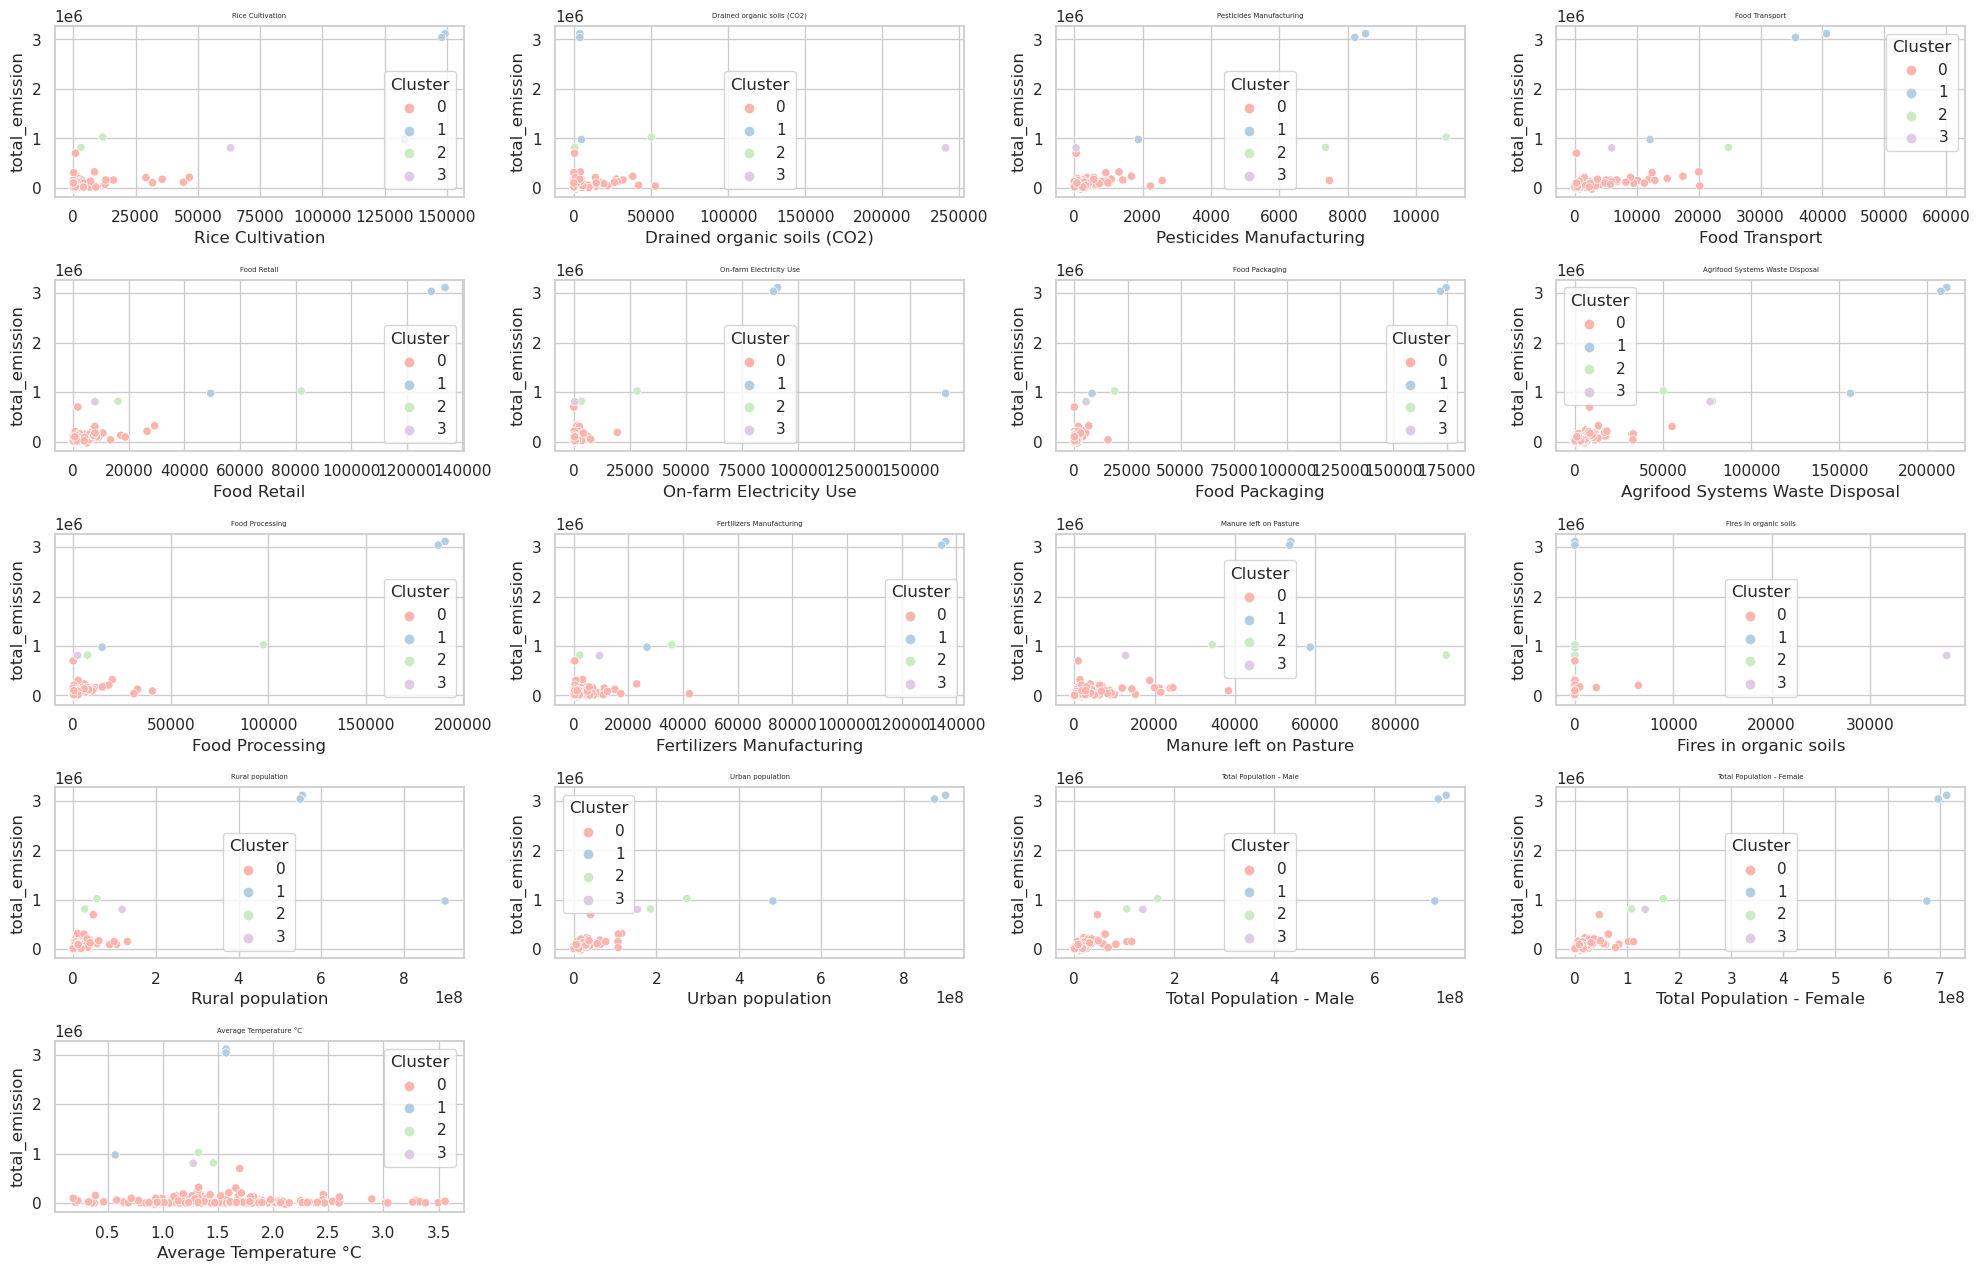

In [ ]:
fig = plt.figure(figsize=(20,20))

for i in range(len(clus_col2)):
    plt.subplot(8,4,i+1)
    sns.scatterplot(df_clus,x=df_clus[clus_col2[i]],y=df_clus['total_emission'],hue=df_clus['Cluster'],palette="Pastel1")
    plt.title(clus_col2[i],fontsize=5)
    
plt.tight_layout()
plt.show()

### 5) Principal component analysis (PCA)

This step reduces the standardized feature space into two principal components to visualize where countries separate along the strongest patterns in the dataset.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=1)
pca.fit(df_sc)
feature = pca.transform(df_sc)

In [ ]:
df_clus['PCA1']=feature[:,0]
df_clus['PCA2']=feature[:,1]

In [ ]:
df_clus.groupby('Cluster')[['PCA1', 'PCA2']].mean().T.plot.bar(figsize=(12, 6))

Cluster,0,1,2,3
PCA1,-0.484190,27.567470,9.438417,5.426811
PCA2,-0.071052,-1.581655,0.202240,20.042998


In [ ]:
pd.DataFrame(pca.components_,columns=df_sc.columns,index=['PCA1','PCA2']).T

,PCA1,PCA2
Rice Cultivation,0.260053,0.083447
Drained organic soils (CO2),0.051623,0.687700
Pesticides Manufacturing,0.220442,-0.040832
Food Transport,0.221131,0.017646
Food Retail,0.274191,-0.054607
On-farm Electricity Use,0.242293,-0.072679
Food Packaging,0.256096,-0.079443
Agrifood Systems Waste Disposal,0.279243,0.063103
Food Processing,0.260585,-0.071099
Fertilizers Manufacturing,0.261540,-0.046232


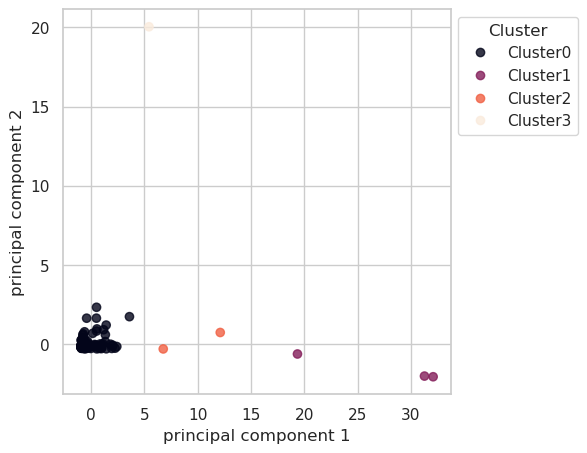

In [ ]:
fig=plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

scatter=ax.scatter(df_clus['PCA1'], df_clus['PCA2'],alpha=0.8, c=cluster)
ax.set_xlabel('principal component 1')
ax.set_ylabel('principal component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Cluster0','Cluster1','Cluster2','Cluster3'],
           title="Cluster",loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
df_clus[(df_clus['Cluster']==1)|(df_clus['Cluster']==2)|(df_clus['Cluster']==3)].loc[:,['Country','Cluster','PCA1','PCA2']]

,Country,Cluster,PCA1,PCA2
27,Brazil,2,6.765028,-0.317495
42,China,1,32.080082,-2.075307
45,"China, mainland",1,31.267808,-2.032755
96,India,1,19.354519,-0.636901
97,Indonesia,3,5.426811,20.042998
215,United States of America,2,12.111807,0.721975


Countries show clear separation in their emission profiles, and population-related variables appear to influence the clustering pattern. The dataset was therefore sorted by total population to help interpret the relationship between scale and emission intensity.

In [ ]:
df_clus['Total_population']=df_clus['Total Population - Male']+ df_clus['Total Population - Female']
df_clus['UrbanPop_ratio']=df_clus['Urban population']/df_clus['Total_population']

In [ ]:
df_clus.sort_values('Total_population', ascending=False).head(10).loc[:,['Country','Cluster','Total_population','UrbanPop_ratio']]

,Country,Cluster,Total_population,UrbanPop_ratio
42,China,1,1.456928e+09,0.619164
45,"China, mainland",1,1.424930e+09,0.614119
96,India,1,1.396387e+09,0.345963
215,United States of America,2,3.359420e+08,0.815543
97,Indonesia,3,2.718580e+08,0.567166
155,Pakistan,0,2.271967e+08,0.340840
27,Brazil,2,2.131963e+08,0.873454
149,Nigeria,0,2.083274e+08,0.514155
16,Bangladesh,0,1.674210e+08,0.387138
170,Russian Federation,0,1.456173e+08,0.738142


**China, India, the USA, Indonesia and Brazil are in Cluster1, Cluster2 or Cluster3.**